# OpenRice — top 30 most-bookmarked (Hong Kong)

Fetches [most-bookmarked chart](https://www.openrice.com/zh/hongkong/explore/chart/most-bookmarked), extracts restaurant **name** and **url**, saves JSON.

**Note:** OpenRice often serves a BytePlus / “Security Check” page to plain `requests`. If that happens, run the Playwright cell (install first) or save the page as HTML from your browser and set `LOCAL_HTML_PATH` below.

In [1]:
# If needed: pip install requests beautifulsoup4 pandas
# Optional for live fetch past bot wall: pip install playwright && playwright install chromium

from __future__ import annotations

import json
import re
from pathlib import Path
from urllib.parse import urljoin, urlparse

import requests
from bs4 import BeautifulSoup

CHART_URL = "https://www.openrice.com/zh/hongkong/explore/chart/most-bookmarked"
TOP_N = 30
OUT_PATH = Path("openrice_top30_bookmarked.json")
# If requests/playwright fail: save the chart page from the browser as HTML and set this path (e.g. Path("cache/most-bookmarked.html"))
LOCAL_HTML_PATH: Path | None = None

HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
        "AppleWebKit/537.36 (KHTML, like Gecko) Chrome/131.0.0.0 Safari/537.36"
    ),
    "Accept-Language": "zh-HK,zh-TW;q=0.9,en;q=0.8",
}

In [2]:
def is_bot_challenge(html: str) -> bool:
    h = html[:12000].lower()
    return "security check" in h or "byteplus" in h


def normalize_url(href: str, base: str = CHART_URL) -> str:
    return urljoin(base, href)


# Hong Kong restaurant POI pages use paths like .../r-r50900/restaurant-name
RESTAURANT_PATH = re.compile(r"/r-r\d+/[^/?#]*", re.IGNORECASE)


def parse_restaurant_links(html: str, base_url: str = CHART_URL) -> list[dict]:
    """Return ordered unique restaurants: {name, url, rank} preserving chart order."""
    soup = BeautifulSoup(html, "html.parser")
    seen: set[str] = set()
    rows: list[dict] = []

    for a in soup.find_all("a", href=True):
        href = a["href"].strip()
        if not href or href.startswith("#"):
            continue
        full = normalize_url(href, base_url)
        path = urlparse(full).path
        if not RESTAURANT_PATH.search(path):
            continue
        # Drop query-only variants of same POI
        canon = full.split("?")[0].rstrip("/") + "/"
        if canon in seen:
            continue
        seen.add(canon)
        name = a.get_text(" ", strip=True)
        if not name:
            # Fallback: last segment of path
            segs = [s for s in path.split("/") if s]
            name = segs[-1].replace("-", " ") if segs else canon
        rows.append({"rank": len(rows) + 1, "name": name, "url": canon.rstrip("/")})
        if len(rows) >= TOP_N:
            break

    return rows

In [3]:
def fetch_html_requests(url: str) -> str:
    r = requests.get(url, headers=HEADERS, timeout=30)
    r.raise_for_status()
    return r.text


html: str | None = None
source = ""

if LOCAL_HTML_PATH is not None and LOCAL_HTML_PATH.exists():
    html = LOCAL_HTML_PATH.read_text(encoding="utf-8", errors="replace")
    source = f"local file: {LOCAL_HTML_PATH}"
else:
    try:
        html = fetch_html_requests(CHART_URL)
        source = "requests"
        if is_bot_challenge(html):
            html = None
            source = "requests (blocked: bot challenge)"
    except Exception as e:
        html = None
        source = f"requests failed: {e}"

print("Fetch source:", source)
if html is not None:
    print("HTML length:", len(html), "| challenge page:", is_bot_challenge(html))

Fetch source: requests
HTML length: 18034 | challenge page: False


<!DOCTYPE html>
<html lang="en">
 <head>
  <meta charset="utf-8"/>
  <link href="data:;base64,=" rel="icon"/>
  <style>
   * { box-sizing: border-box; } html, body { height: 100%; } body { margin: 0; background: #fff; color: #0c0d0e; font-family: -apple-system, BlinkMacSystemFont, "PingFang SC", "Hiragino Sans GB", "Microsoft YaHei", Arial, sans-serif; } .page { min-height: 100vh; padding: min(300px, 22vh) 20px 40px; display: flex; flex-direction: column; align-items: center; } .card { width: 432px; max-width: 100%; padding: 20px; border: 1px solid #ebf1ff; border-radius: 12px; background: linear-gradient( 50.55deg, rgba(241, 249, 255, 0.2) -3.67%, rgba(237, 243, 255, 0.2) 51.14%, rgba(250, 244, 255, 0.2) 99.1% ); margin-bottom: 40px; } .brand { display: flex; align-items: center; color: #162033; font-size: 14px; font-weight: 600; line-height: 1; white-space: nowrap; margin-bottom: 20px; } .brand img { margin-right: 8px; display: block; width: 18px; height: 16px; } .brand span { letter
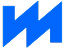

In [8]:
bs = BeautifulSoup(html)
print(bs.prettify())

## Optional: Playwright (if `requests` gets the security check)

Run: `pip install playwright` then `playwright install chromium` in the same environment as this kernel.

In [9]:
def fetch_html_playwright(url: str, wait_ms: int = 8000) -> str:
    from playwright.sync_api import sync_playwright

    with sync_playwright() as p:
        browser = p.chromium.launch(headless=True)
        try:
            page = browser.new_page(user_agent=HEADERS["User-Agent"])
            page.goto(url, wait_until="domcontentloaded", timeout=60_000)
            page.wait_for_timeout(wait_ms)
            return page.content()
        finally:
            browser.close()


# Uncomment to try Playwright when requests returns the challenge page:
html = fetch_html_playwright(CHART_URL)
source = "playwright"
print("After playwright, challenge:", is_bot_challenge(html), "len:", len(html))

ModuleNotFoundError: No module named 'playwright'

In [5]:
if html is None or is_bot_challenge(html):
    raise RuntimeError(
        "No usable HTML. Options: (1) set LOCAL_HTML_PATH to a saved chart HTML file, "
        "(2) uncomment the Playwright fetch in the cell above and install playwright, "
        "(3) run this notebook on a network where requests is not challenged."
    )

restaurants = parse_restaurant_links(html, CHART_URL)
payload = {
    "source_url": CHART_URL,
    "fetched_via": source,
    "count": len(restaurants),
    "restaurants": restaurants,
}

OUT_PATH.write_text(json.dumps(payload, ensure_ascii=False, indent=2), encoding="utf-8")
print(f"Wrote {len(restaurants)} rows to {OUT_PATH.resolve()}")
payload

Wrote 0 rows to /Users/benkan45d6/GitHub/Intro-To-DataScience/working/openrice_top30_bookmarked.json


{'source_url': 'https://www.openrice.com/zh/hongkong/explore/chart/most-bookmarked',
 'fetched_via': 'requests',
 'count': 0,
 'restaurants': []}

In [6]:
import pandas as pd

pd.DataFrame(restaurants)

""
